<a href="https://colab.research.google.com/github/YashitaaArya/Python-Practices/blob/main/HMDCategoricalImputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDLING MISSING DATA**

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
df=pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [69]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


regression problem

In [70]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

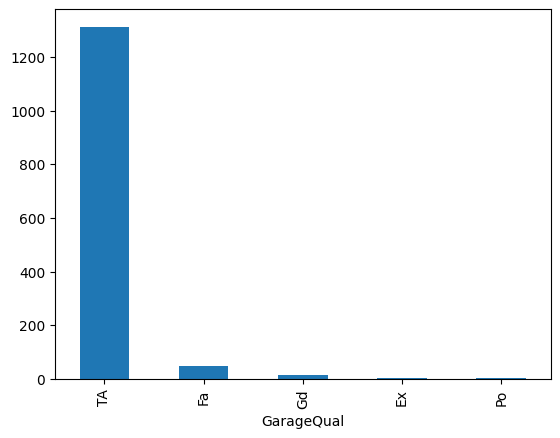

In [71]:
df['GarageQual'].value_counts().plot(kind='bar')

In [72]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0.5, 1.0, 'GarageQual vs SalePrice')

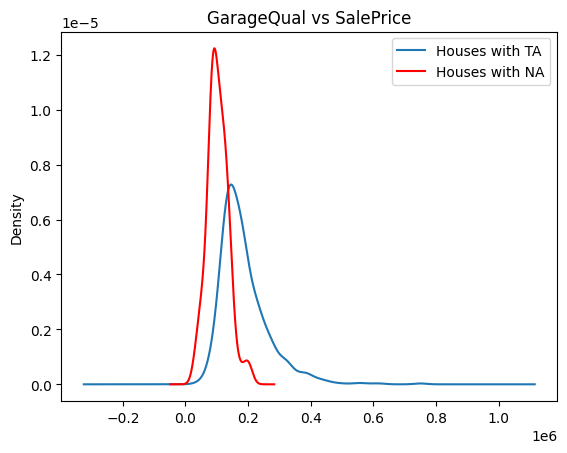

In [73]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels=['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual vs SalePrice')

In [74]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [75]:
df['GarageQual'].fillna('TA', inplace=True)

/tmp/ipykernel_2175/1818999247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


we replaced all missing values with only TA



<Axes: xlabel='GarageQual'>

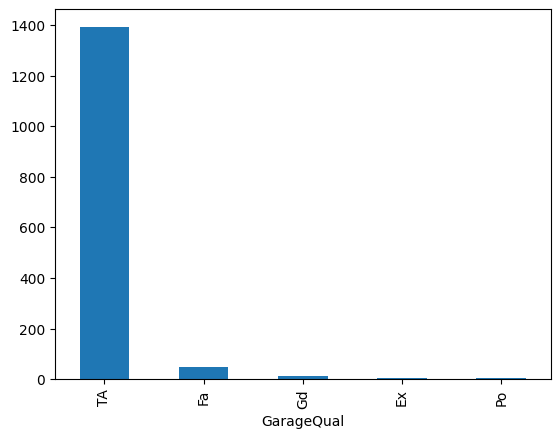

In [76]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

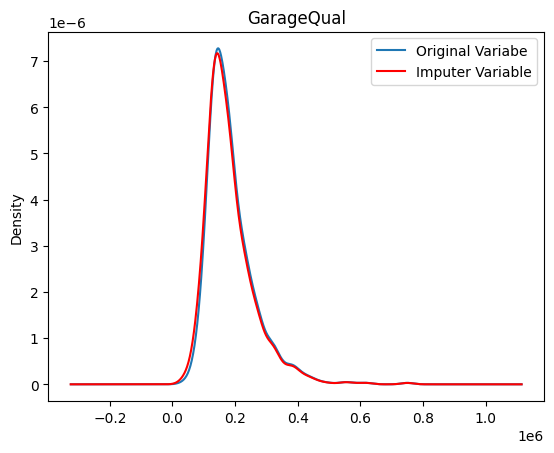

In [77]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels=['Original Variabe', 'Imputer Variable']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

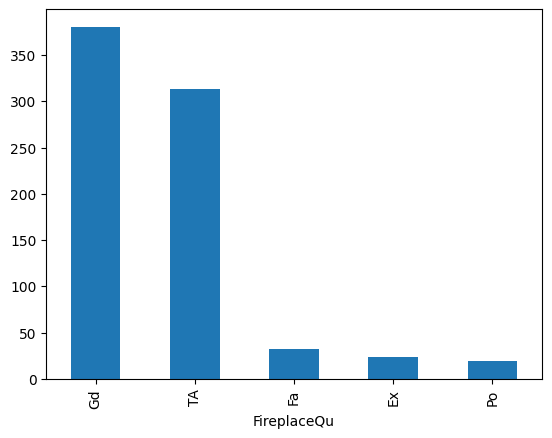

In [78]:
df['FireplaceQu'].value_counts().plot(kind='bar')

here two categories are dominant, not just a single one.

In [79]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

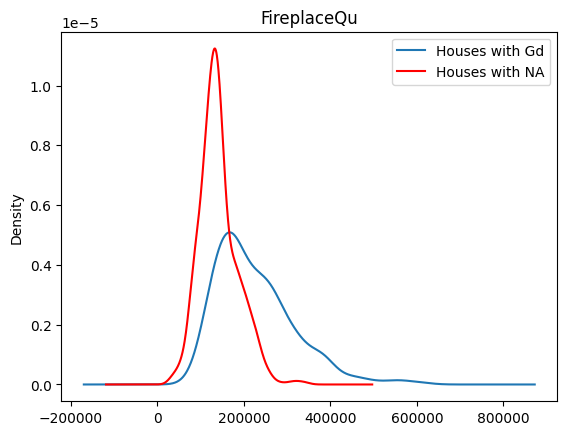

In [80]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels=['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')
#

In [81]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']

In [82]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_2175/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


we replaced all missing values with only Gd


<Axes: xlabel='FireplaceQu'>

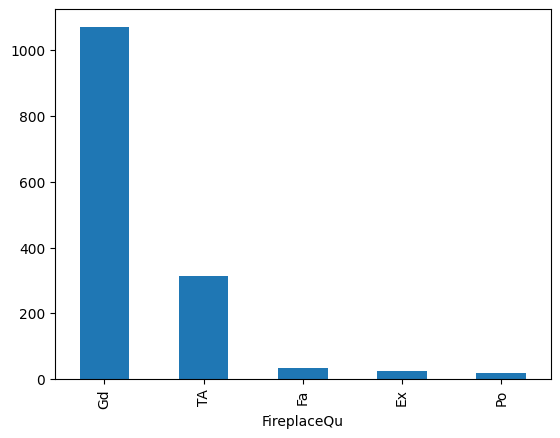

In [83]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

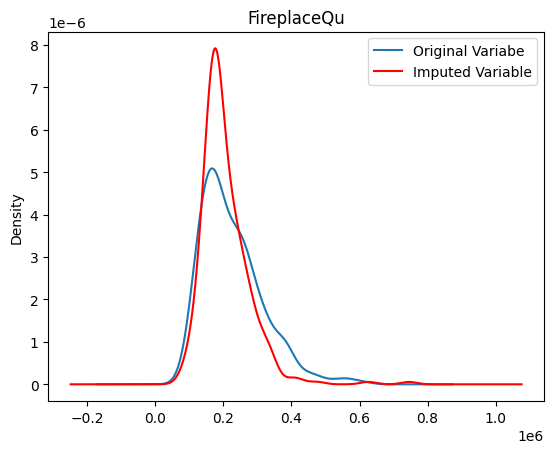

In [84]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

df[df['FireplaceQu']=='TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels=['Original Variabe', 'Imputed Variable']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

this destroyed good data in fireplace col

In [85]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2)

In [86]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='most_frequent')

In [87]:
x_train=si.fit_transform(x_train)
x_test=si.transform(x_test)

In [88]:
si.statistics_

array(['Gd', 'TA'], dtype=object)

MISSING CATEGORY IMPUTATION

In [89]:
newdf=pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [90]:
newdf['GarageQual'].fillna('Missing', inplace=True)

/tmp/ipykernel_2175/1862281222.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['GarageQual'].fillna('Missing', inplace=True)


Text(0, 0.5, 'Number of houses')

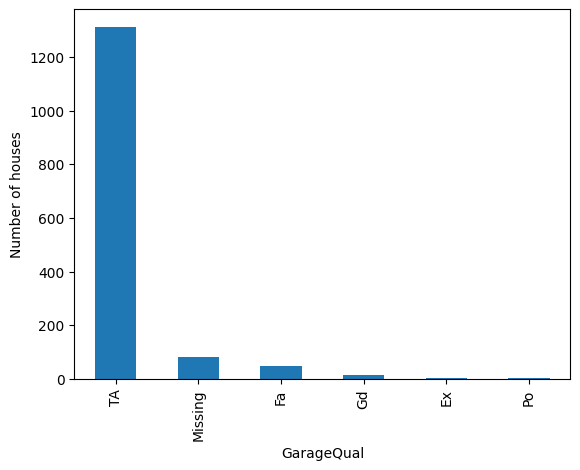

In [91]:
newdf['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

using scikit-learn

In [96]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(newdf.drop(columns=['SalePrice']), newdf['SalePrice'], test_size=0.2)

In [97]:
from sklearn.impute import SimpleImputer

In [98]:
imputer=SimpleImputer(strategy='most_frequent', fill_value='Missing')

In [99]:
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

In [100]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)